# Spindle-count scaling experiment: vibration-illusion analysis

Analyzes the models trained by `spindle_scaling_experiment_gpu.sh` (n_aff = 15, 30, ..., 150, seeds 0/2/4) using the vibration-illusion test data produced by `test_vibrations/vibrations_scaling_experiment.sh`.

**Run that script first** -- this notebook only loads and analyzes its output, it does not run any vibration inference itself. If some (n_aff, seed) combinations haven't been tested yet, the cells below skip them and note what's missing rather than failing.

Contents:
1. Load vibration-test results for every available (n_aff, seed) model
2. **Figure A**: perceived elbow-angle offset vs. vibration frequency, one figure per (n_aff, muscle group) -- 20 figures, styled like Figure 4 of the paper
3. **Similarity table**: ICC(3,1) between the 3 seeds' curves, one row per Figure-A panel
4. **Figure B**: perceived illusion angle vs. number of afferents, one figure per (vibration frequency, muscle group)

## Setup

In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats as scipy_stats

from directory_paths import SAVE_DIR
from utils.analysis_plots_helper import (
    ALPHA,
    BASE_FIG_SIZE_1COL,
    LW,
    LW_SMALL,
    MARKER_LIST,
    MS,
    SAMPLE_RATE,
    generate_color_gradient,
    load_vibration_data,
    original_hex_biceps,
    original_hex_tri,
    set_publication_style,
)

set_publication_style()

In [ ]:
# Model tree: hardcoded rather than read from directory_paths.MODELS_DIR, since that
# reads the MODELS_DIR env var at import time -- this notebook's kernel may not have
# it set even though the sweep/vibration scripts exported it for their own processes.
ROOT_DIR = "/media/data16/siebe"
MODELS_DIR_NAME = "trained_models_spindle_scaling"
MODEL_ROOT = os.path.join(ROOT_DIR, MODELS_DIR_NAME)

# where sampled-coefficient CSVs and (per inference/test_scaling_experiment_gpu.py)
# test_performance.csv live -- must match spindle_scaling_experiment_gpu.sh's EXPERIMENT_DIR
DATA_DIR = "/media/data16/siebe/datasets"
EXPERIMENT_DIR = os.path.join(DATA_DIR, "spindle_scaling_experiment_gpu")

DATA_PATH_PREFIX = "spindle_scaling_gpu"
TASK = "letter_reconstruction_joints"
N_AFF_LEVELS = [15, 30, 45, 60, 75, 90, 105, 120, 135, 150]
SEEDS_TO_LOAD = ["0", "1", "2", "3", "4"]  # coef_seed == training_seed for this sweep -- seeds
# 1/3 trained on a different machine, merged into the same MODEL_ROOT/EXPERIMENT_DIR tree

# must match test_vibrations/vibrations_scaling_experiment.sh
INPUT_DATA = "ES3D"
TEST_EXP_DIR = "vib_vary_multipleFs_vib_ia_only"
COLUMNS_TO_LOAD = ["vib_freq", "vib_muscles", "trial", "elbow_angle", "vib_angle_diff_elbow"]

# original-paper colors: biceps red, triceps teal (utils/analysis_plots_helper.py)
MUSCLE_COLOR_MAP = {
    "TRIlat_TRIlong_TRImed": original_hex_tri,
    "BIClong_BICshort": original_hex_biceps,
}
MUSCLE_LABEL_MAP = {
    "TRIlat_TRIlong_TRImed": "triceps",
    "BIClong_BICshort": "biceps",
}

FIG_DIR = "figures_spindle_scaling_analysis"
FIG_A_DIR = os.path.join(FIG_DIR, "figA_freq_response")
FIG_B_DIR = os.path.join(FIG_DIR, "figB_spindleCount_vs_illusion")
FIG_C_DIR = os.path.join(FIG_DIR, "figC_seedStd_vs_freq")
FIG_D_DIR = os.path.join(FIG_DIR, "figD_meanSeedStd_vs_spindleCount")
FIG_E_DIR = os.path.join(FIG_DIR, "figE_testPerformance_vs_spindleCount")
os.makedirs(FIG_A_DIR, exist_ok=True)
os.makedirs(FIG_B_DIR, exist_ok=True)
os.makedirs(FIG_C_DIR, exist_ok=True)
os.makedirs(FIG_D_DIR, exist_ok=True)
os.makedirs(FIG_E_DIR, exist_ok=True)

In [ ]:
# Toggle: combine Figure A's ~20 panels (and Figure B's ~22) into one subplot grid per
# figure instead of one saved file per panel. Individual mode (default) keeps every
# panel as its own file, e.g. for picking a single panel out for a paper; grid mode is
# handy for a quick visual scan across the whole n_aff sweep.
COMBINE_INTO_SUBPLOTS = False

## 1. Load vibration-test data

Reads `vib_results.h5` files written by `test_vibrations/vibrations_scaling_experiment.sh`, one `load_vibration_data()` call per n_aff level (each level has its own experiment/model directory), tagging each with its `n_aff` before concatenating.

In [ ]:
dfs = []
missing_n_aff = []

for n_aff in N_AFF_LEVELS:
    exp_dir = os.path.join(
        MODEL_ROOT,
        f"experiment_causal_flag-pcr_{DATA_PATH_PREFIX}_{n_aff}_{n_aff}_{TASK}",
    )
    if not os.path.isdir(exp_dir):
        print(f"n_aff={n_aff}: experiment directory not found yet, skipping ({exp_dir})")
        missing_n_aff.append(n_aff)
        continue
    try:
        df_n = load_vibration_data(
            model_path=exp_dir,
            test_exp_dir=TEST_EXP_DIR,
            vib_muscles=None,
            vib_range=None,
            columns_to_load=COLUMNS_TO_LOAD,
            coef_seeds_to_load=SEEDS_TO_LOAD,
            train_seeds_to_load=SEEDS_TO_LOAD,
            input_data=INPUT_DATA,
            sample_rate=SAMPLE_RATE,
            exact_vib_muscles=True,
        )
    except ValueError:
        print(f"n_aff={n_aff}: no vib_results.h5 found yet, skipping")
        missing_n_aff.append(n_aff)
        continue

    df_n["n_aff"] = n_aff
    dfs.append(df_n)
    seeds_present = sorted(df_n["coef_seed"].unique())
    print(f"n_aff={n_aff}: loaded {len(df_n)} rows, seeds present = {seeds_present}")

if not dfs:
    raise RuntimeError(
        "No vibration data found for any n_aff level -- run "
        "test_vibrations/vibrations_scaling_experiment.sh first."
    )

df_all = pd.concat(dfs, ignore_index=True)
df_all = df_all[df_all["vib_muscles_str"].isin(MUSCLE_COLOR_MAP.keys())].reset_index(drop=True)

if missing_n_aff:
    print(f"\nNote: no data yet for n_aff = {missing_n_aff} -- figures/table below only cover what's loaded.")

df_all.head()

### Optional: dummy data for figure inspection

Run the cell below **instead of** (or after) the real loading cell above to populate `df_all` with synthetic values in the same schema, so every figure/table below can be inspected before `test_vibrations/vibrations_scaling_experiment.sh` has actually produced real results. Delete this cell once real data is available -- it isn't part of the analysis.

In [3]:
# DUMMY DATA -- see markdown note above. Overwrites df_all with synthetic values shaped
# like the real thing: illusion magnitude grows (saturating) with n_aff, trial noise
# shrinks with n_aff, triceps/biceps have opposite sign, each seed gets a small fixed
# offset so curves aren't identical, and frequency response rises then decays -- all
# just plausible-looking, not physiologically meaningful.
rng = np.random.default_rng(42)
NUM_TRIALS_DUMMY = 100
VIB_FREQS_DUMMY = [0, 20, 40, 60, 80, 100, 110, 130, 150, 170, 190]

dummy_rows = []
for n_aff in N_AFF_LEVELS:
    amplitude = 20 * (1 - np.exp(-n_aff / 50))  # illusion magnitude grows with more afferents
    noise_sd = 6 * np.exp(-n_aff / 120) + 1  # trial noise shrinks with more afferents
    for muscle_group, label in MUSCLE_LABEL_MAP.items():
        muscle_sign = 1.0 if label == "triceps" else -1.0
        muscle_list = muscle_group.split("_")
        for seed in SEEDS_TO_LOAD:
            seed_offset = rng.normal(0, 0.15 * amplitude)  # small fixed per-seed offset
            seed_scale = 1 + rng.normal(0, 0.08)
            for freq in VIB_FREQS_DUMMY:
                mean_response = (
                    muscle_sign * seed_scale * amplitude * (freq / (freq + 50)) * np.exp(-freq / 250)
                    + seed_offset
                )
                trial_values = rng.normal(mean_response, noise_sd, size=NUM_TRIALS_DUMMY)
                elbow_angles = rng.uniform(30, 150, size=NUM_TRIALS_DUMMY)
                for trial in range(NUM_TRIALS_DUMMY):
                    dummy_rows.append(
                        {
                            "vib_freq": freq,
                            "vib_muscles": muscle_list,
                            "trial": trial,
                            "elbow_angle": elbow_angles[trial],
                            "vib_angle_diff_elbow": trial_values[trial],
                            "seed_path": f"spatiotemporal_4_{seed}_{seed}",
                            "coef_seed": seed,
                            "train_seed": seed,
                            "vib_muscles_str": muscle_group,
                            "n_aff": n_aff,
                        }
                    )

df_all = pd.DataFrame(dummy_rows)
print(
    f"generated {len(df_all)} dummy rows across {len(N_AFF_LEVELS)} n_aff levels, "
    f"{df_all['coef_seed'].nunique()} seeds, {df_all['vib_muscles_str'].nunique()} muscle groups"
)
df_all.head()

generated 66000 dummy rows across 10 n_aff levels, 3 seeds, 2 muscle groups


,vib_freq,vib_muscles,trial,elbow_angle,vib_angle_diff_elbow,seed_path,coef_seed,train_seed,vib_muscles_str,n_aff
0,0,"[TRIlat, TRIlong, TRImed]",0,123.450108,4.961008,spatiotemporal_4_0_0,0,0,TRIlat_TRIlong_TRImed,15
1,0,"[TRIlat, TRIlong, TRImed]",1,116.026823,6.157769,spatiotemporal_4_0_0,0,0,TRIlat_TRIlong_TRImed,15
2,0,"[TRIlat, TRIlong, TRImed]",2,83.923380,-12.044799,spatiotemporal_4_0_0,0,0,TRIlat_TRIlong_TRImed,15
3,0,"[TRIlat, TRIlong, TRImed]",3,62.668987,-7.960264,spatiotemporal_4_0_0,0,0,TRIlat_TRIlong_TRImed,15
4,0,"[TRIlat, TRIlong, TRImed]",4,41.566915,1.041684,spatiotemporal_4_0_0,0,0,TRIlat_TRIlong_TRImed,15


In [4]:
# seed -> marker shape, built from the seeds actually present (coef_seed is a string
# column, e.g. "0"/"2"/"4" -- analysis_plots_helper's own module-level seed_marker_map
# is int-keyed 0-9 and would KeyError here, same reason fig4_vibrations_robustness.ipynb
# builds its own)
unique_seeds = sorted(df_all["coef_seed"].unique())
seed_marker_map = {seed: MARKER_LIST[i] for i, seed in enumerate(unique_seeds)}

print(f"{len(df_all)} rows total")
print("n_aff levels loaded:", sorted(df_all["n_aff"].unique()))
print("coef_seeds:", unique_seeds)
print("muscle groups:", list(df_all["vib_muscles_str"].unique()))
print("vib_freqs:", sorted(df_all["vib_freq"].unique()))

66000 rows total
n_aff levels loaded: [np.int64(15), np.int64(30), np.int64(45), np.int64(60), np.int64(75), np.int64(90), np.int64(105), np.int64(120), np.int64(135), np.int64(150)]
coef_seeds: ['0', '2', '4']
muscle groups: ['TRIlat_TRIlong_TRImed', 'BIClong_BICshort']
vib_freqs: [np.int64(0), np.int64(20), np.int64(40), np.int64(60), np.int64(80), np.int64(100), np.int64(110), np.int64(130), np.int64(150), np.int64(170), np.int64(190)]


## 2. Figure A: perceived angle vs. vibration frequency (Figure-4 style)

One panel per (n_aff, muscle group) -- 10 n_aff levels x 2 muscle groups = 20 figures by default (fewer if `COMBINE_INTO_SUBPLOTS` above is `True`, all 20 land in one grid figure instead). Each panel overlays the 3 seeds' curves (shaded by `generate_color_gradient`, same helper Figure 4 uses) on the muscle group's base color: triceps teal, biceps red -- matching the original paper.

Plotted with a local `draw_freq_response_curve` helper (same jittered-scatter + mean-line visual style as `plot_angleOffset_vs_vibration`, which `fig4_vibrations_robustness.ipynb` uses) rather than that shared function directly, since it needs to (a) accept an externally-supplied `ax` for grid mode and (b) place the legend outside the axes -- neither of which the shared version supports, and changing its default behavior would affect every other notebook that calls it.

In [ ]:
def draw_freq_response_curve(ax, df_panel, base_color, seed_marker_map, per_seed_col="coef_seed",
                              col_name="vib_angle_diff_elbow", jitter_strength=3, rng=None):
    """Draws per-seed jittered-scatter + mean-line curves into ax.

    Mirrors utils.analysis_plots_helper.plot_angleOffset_vs_vibration's visual style
    (same color-gradient/marker scheme), reimplemented locally so it can plot into a
    caller-supplied ax (needed for subplot-grid mode) and so legend placement is
    controlled by the caller instead of drawn inside the axes.

    Returns (handles, labels) for the caller to build a legend from -- this function
    never adds a legend itself, since grid mode wants one shared legend for the whole
    figure rather than one repeated per panel.
    """
    if rng is None:
        rng = np.random.default_rng(0)
    seeds = sorted(df_panel[per_seed_col].unique())
    grad = generate_color_gradient(base_color, num_shades=len(seeds))

    handles, labels = [], []
    for i, seed in enumerate(seeds):
        seed_data = df_panel[df_panel[per_seed_col] == seed]
        aggregated = (
            seed_data.groupby(["trial", "vib_freq"])
            .agg(col_name_mean=(col_name, "mean"))
            .reset_index()
        )
        jittered_freqs = aggregated["vib_freq"] + rng.uniform(
            -jitter_strength, jitter_strength, size=len(aggregated)
        )
        ax.scatter(
            jittered_freqs,
            aggregated["col_name_mean"],
            color=grad[i],
            edgecolor="black",
            alpha=ALPHA,
            marker=seed_marker_map[seed],
            s=MS,
        )
        mean_line = aggregated.groupby("vib_freq")["col_name_mean"].mean()
        (line,) = ax.plot(mean_line.index, mean_line.values, color=grad[i], lw=LW)
        handles.append(line)
        labels.append(f"seed {seed}")

    ax.axhline(0, linestyle="dashed", color="black", lw=LW_SMALL)
    return handles, labels

In [ ]:
FIGA_YLIM = 90  # deg -- adjust and rerun this cell if any curve clips

if not COMBINE_INTO_SUBPLOTS:
    for n_aff in N_AFF_LEVELS:
        for muscle_group, color in MUSCLE_COLOR_MAP.items():
            df_f = df_all[(df_all["n_aff"] == n_aff) & (df_all["vib_muscles_str"] == muscle_group)]
            if df_f.empty:
                continue

            fig, ax = plt.subplots(figsize=BASE_FIG_SIZE_1COL)
            handles, labels = draw_freq_response_curve(ax, df_f, color, seed_marker_map)
            if FIGA_YLIM is not None:
                ax.set_ylim(-FIGA_YLIM, FIGA_YLIM)
            ax.set_xlabel("Vibration Frequency (Hz)")
            ax.set_ylabel("Predicted elbow angle diff. (deg)")
            ax.set_title(f"n_aff={n_aff}, {MUSCLE_LABEL_MAP[muscle_group]}")
            # legend outside the axes, to the right, instead of matplotlib's default
            # "best" placement (which can land on top of the data)
            ax.legend(handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0)

            fig.tight_layout()
            fname = os.path.join(FIG_A_DIR, f"naff{n_aff}_{MUSCLE_LABEL_MAP[muscle_group]}")
            fig.savefig(fname + ".svg", format="svg", bbox_inches="tight")
            fig.savefig(fname + ".png", bbox_inches="tight")
            plt.show()
            plt.close(fig)

else:
    muscle_items = list(MUSCLE_COLOR_MAP.items())
    n_rows, n_cols = len(muscle_items), len(N_AFF_LEVELS)
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(2.0 * n_cols, 2.2 * n_rows),
        sharex=True, sharey=True, constrained_layout=True,
    )
    axes = np.atleast_2d(axes)
    legend_handles = legend_labels = None

    for r, (muscle_group, color) in enumerate(muscle_items):
        for c, n_aff in enumerate(N_AFF_LEVELS):
            ax = axes[r, c]
            df_f = df_all[(df_all["n_aff"] == n_aff) & (df_all["vib_muscles_str"] == muscle_group)]
            if df_f.empty:
                ax.axis("off")
                continue

            handles, labels = draw_freq_response_curve(ax, df_f, color, seed_marker_map)
            if legend_handles is None:
                legend_handles, legend_labels = handles, labels
            if FIGA_YLIM is not None:
                ax.set_ylim(-FIGA_YLIM, FIGA_YLIM)
            if r == 0:
                ax.set_title(f"n_aff={n_aff}", fontsize=8)
            if c == 0:
                ax.set_ylabel(MUSCLE_LABEL_MAP[muscle_group], fontsize=8)
            ax.tick_params(labelsize=6)

    # hide redundant tick labels on inner panels of the shared-axis grid, and use one
    # shared x/y label + one shared legend below the whole grid instead of repeating
    # them per panel -- both keep small-panel labels from overlapping or clipping
    for ax in axes.flat:
        ax.label_outer()
    fig.supxlabel("Vibration Frequency (Hz)")
    fig.supylabel("Predicted elbow angle diff. (deg)")
    if legend_handles is not None:
        fig.legend(
            legend_handles, legend_labels,
            loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=len(legend_labels),
        )

    fname = os.path.join(FIG_A_DIR, "all_panels_grid")
    fig.savefig(fname + ".svg", format="svg", bbox_inches="tight")
    fig.savefig(fname + ".png", bbox_inches="tight")
    plt.show()
    plt.close(fig)

## 3. Similarity between seeds: ICC(3,1)

For each Figure-A panel, treats the 3 seeds as fixed raters and the 11 vibration frequencies as repeated subjects, and computes the two-way mixed-effects intraclass correlation coefficient, ICC(3,1) -- the standard agreement measure for a specific, fixed set of raters (as opposed to ICC(2,*), which assumes raters are themselves a random sample). Input to each ICC is the trial-averaged `vib_angle_diff_elbow` per (seed, frequency) cell.

Reported alongside ICC(3,1) (single-seed reliability) is ICC(3,k) (reliability of the 3-seed mean curve) and a 95% CI computed from the F-distribution (McGraw & Wong, 1996) -- implemented directly with `scipy.stats.f` since neither `pingouin` nor `statsmodels` is installed in this environment, and the formula is a handful of lines.

In [6]:
def icc_3_1(matrix):
    """ICC(3,1) and ICC(3,k): two-way mixed effects, consistency.

    matrix: (n_subjects, k_raters) array -- here (n_frequencies, n_seeds).
    ICC(3,*) treats raters (seeds) as a fixed, specific set (not sampled from
    a rater population), which matches this sweep: every panel uses exactly
    seeds 0/2/4, not a random draw of seeds.

    Returns (icc_3_1, ci_lower, ci_upper, icc_3_k).
    """
    matrix = np.asarray(matrix, dtype=float)
    n, k = matrix.shape
    grand_mean = matrix.mean()
    row_means = matrix.mean(axis=1)
    col_means = matrix.mean(axis=0)

    ss_total = np.sum((matrix - grand_mean) ** 2)
    ss_rows = k * np.sum((row_means - grand_mean) ** 2)
    ss_cols = n * np.sum((col_means - grand_mean) ** 2)
    ss_error = ss_total - ss_rows - ss_cols

    df_rows = n - 1
    df_error = (n - 1) * (k - 1)

    ms_rows = ss_rows / df_rows
    ms_error = ss_error / df_error

    icc = (ms_rows - ms_error) / (ms_rows + (k - 1) * ms_error)
    icc_k = (ms_rows - ms_error) / ms_rows

    f_stat = ms_rows / ms_error
    f_upper_crit = scipy_stats.f.ppf(0.975, df_rows, df_error)
    f_lower_crit = scipy_stats.f.ppf(0.975, df_error, df_rows)
    f_lo = f_stat / f_upper_crit
    f_hi = f_stat * f_lower_crit
    ci_lower = (f_lo - 1) / (f_lo + k - 1)
    ci_upper = (f_hi - 1) / (f_hi + k - 1)

    return icc, ci_lower, ci_upper, icc_k

In [7]:
icc_rows = []

for n_aff in N_AFF_LEVELS:
    for muscle_group, label in MUSCLE_LABEL_MAP.items():
        df_f = df_all[(df_all["n_aff"] == n_aff) & (df_all["vib_muscles_str"] == muscle_group)]
        if df_f.empty:
            continue

        # mean vib_angle_diff_elbow per (seed, freq), across trials -> (freq x seed) matrix
        agg = (
            df_f.groupby(["coef_seed", "vib_freq"])["vib_angle_diff_elbow"]
            .mean()
            .unstack("coef_seed")
            .sort_index()
        )
        agg = agg.dropna(axis=0, how="any")  # keep only freqs with every seed present
        if agg.shape[0] < 2 or agg.shape[1] < 2:
            print(f"n_aff={n_aff} {label}: not enough complete (seed, freq) data for ICC, skipping")
            continue

        icc, ci_lo, ci_hi, icc_k = icc_3_1(agg.values)
        icc_rows.append(
            {
                "n_aff": n_aff,
                "muscle_group": label,
                "n_seeds": agg.shape[1],
                "n_frequencies": agg.shape[0],
                "ICC(3,1)": icc,
                "95% CI low": ci_lo,
                "95% CI high": ci_hi,
                "ICC(3,k)": icc_k,
            }
        )

icc_table = pd.DataFrame(icc_rows).sort_values(["muscle_group", "n_aff"]).reset_index(drop=True)
icc_table

,n_aff,muscle_group,n_seeds,n_frequencies,"ICC(3,1)",95% CI low,95% CI high,"ICC(3,k)"
0,15,biceps,3,11,0.495271,0.123285,0.806227,0.746437
1,30,biceps,3,11,0.857213,0.661164,0.955215,0.947397
2,45,biceps,3,11,0.863412,0.673829,0.957294,0.949909
3,60,biceps,3,11,0.969688,0.918835,0.991005,0.989688
4,75,biceps,3,11,0.921537,0.800847,0.976166,0.972402
5,90,biceps,3,11,0.968819,0.916590,0.990743,0.989386
6,105,biceps,3,11,0.975728,0.934557,0.992818,0.991776
7,120,biceps,3,11,0.987696,0.966362,0.996380,0.995865
8,135,biceps,3,11,0.982876,0.953446,0.994950,0.994226
9,150,biceps,3,11,0.976707,0.937125,0.993111,0.992113


In [8]:
icc_table_path = os.path.join(FIG_DIR, "seed_similarity_ICC.csv")
icc_table.to_csv(icc_table_path, index=False)
print(f"saved ICC table to {icc_table_path}")

saved ICC table to figures_spindle_scaling_analysis/seed_similarity_ICC.csv


## 4. Figure B: perceived illusion angle vs. number of afferents

One figure per (vibration frequency, muscle group) -- 11 frequencies x 2 muscle groups = 22 figures by default (one grid figure instead if `COMBINE_INTO_SUBPLOTS` above is `True`). x-axis is the number of Ia afferents per muscle (the n_aff sweep), y-axis is the trial-averaged perceived elbow-angle offset. Each of the 3 seeds is its own line/marker series, colored by seed shade within the muscle group's base color (same `generate_color_gradient` convention as Figure A), so a panel directly shows how the illusion at that frequency scales with spindle count and how consistent that trend is across seeds.

In [ ]:
FIGB_YLIM = None  # deg -- set a number to fix the y-range across panels, or leave None for auto

vib_freqs_sorted = sorted(df_all["vib_freq"].unique())


def draw_spindleCount_curve(ax, df_freq, seeds_here, seed_color, seed_marker_map):
    """Draws one seed-colored line per seed (illusion vs. n_aff) into ax. Returns
    (handles, labels) -- doesn't add a legend itself, same reasoning as
    draw_freq_response_curve above."""
    handles, labels = [], []
    for seed in seeds_here:
        df_seed = df_freq[df_freq["coef_seed"] == seed].sort_values("n_aff")
        if df_seed.empty:
            continue
        (line,) = ax.plot(
            df_seed["n_aff"],
            df_seed["vib_angle_diff_elbow"],
            color=seed_color[seed],
            marker=seed_marker_map[seed],
            markeredgecolor="black",
            alpha=ALPHA,
            lw=LW,
            markersize=6,
        )
        handles.append(line)
        labels.append(f"seed {seed}")
    ax.axhline(0, linestyle="dashed", color="black", lw=LW_SMALL)
    return handles, labels


if not COMBINE_INTO_SUBPLOTS:
    for muscle_group, color in MUSCLE_COLOR_MAP.items():
        label = MUSCLE_LABEL_MAP[muscle_group]
        df_m = df_all[df_all["vib_muscles_str"] == muscle_group]
        if df_m.empty:
            continue

        agg = (
            df_m.groupby(["n_aff", "coef_seed", "vib_freq"])["vib_angle_diff_elbow"]
            .mean()
            .reset_index()
        )
        seeds_here = sorted(agg["coef_seed"].unique())
        grad = generate_color_gradient(color, num_shades=len(seeds_here))
        seed_color = {seed: grad[i] for i, seed in enumerate(seeds_here)}

        for freq in vib_freqs_sorted:
            df_freq = agg[agg["vib_freq"] == freq]
            if df_freq.empty:
                continue

            fig, ax = plt.subplots(figsize=BASE_FIG_SIZE_1COL)
            handles, labels = draw_spindleCount_curve(ax, df_freq, seeds_here, seed_color, seed_marker_map)
            if FIGB_YLIM is not None:
                ax.set_ylim(-FIGB_YLIM, FIGB_YLIM)
            ax.set_xlabel("Number of Ia afferents per muscle")
            ax.set_ylabel("Predicted elbow angle diff. (deg)")
            ax.set_title(f"{label}, {freq} Hz")
            ax.legend(handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0)

            fig.tight_layout()
            fname = os.path.join(FIG_B_DIR, f"illusion_vs_spindleCount_{label}_{freq}Hz")
            fig.savefig(fname + ".svg", format="svg", bbox_inches="tight")
            fig.savefig(fname + ".png", bbox_inches="tight")
            plt.show()
            plt.close(fig)

else:
    muscle_items = list(MUSCLE_COLOR_MAP.items())
    n_rows, n_cols = len(muscle_items), len(vib_freqs_sorted)
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(2.0 * n_cols, 2.2 * n_rows),
        sharex=True, sharey=True, constrained_layout=True,
    )
    axes = np.atleast_2d(axes)
    legend_handles = legend_labels = None

    for r, (muscle_group, color) in enumerate(muscle_items):
        label = MUSCLE_LABEL_MAP[muscle_group]
        df_m = df_all[df_all["vib_muscles_str"] == muscle_group]
        if df_m.empty:
            for c in range(n_cols):
                axes[r, c].axis("off")
            continue

        agg = (
            df_m.groupby(["n_aff", "coef_seed", "vib_freq"])["vib_angle_diff_elbow"]
            .mean()
            .reset_index()
        )
        seeds_here = sorted(agg["coef_seed"].unique())
        grad = generate_color_gradient(color, num_shades=len(seeds_here))
        seed_color = {seed: grad[i] for i, seed in enumerate(seeds_here)}

        for c, freq in enumerate(vib_freqs_sorted):
            ax = axes[r, c]
            df_freq = agg[agg["vib_freq"] == freq]
            if df_freq.empty:
                ax.axis("off")
                continue

            handles, labels = draw_spindleCount_curve(ax, df_freq, seeds_here, seed_color, seed_marker_map)
            if legend_handles is None:
                legend_handles, legend_labels = handles, labels
            if FIGB_YLIM is not None:
                ax.set_ylim(-FIGB_YLIM, FIGB_YLIM)
            if r == 0:
                ax.set_title(f"{freq} Hz", fontsize=8)
            if c == 0:
                ax.set_ylabel(label, fontsize=8)
            ax.tick_params(labelsize=6)

    for ax in axes.flat:
        ax.label_outer()
    fig.supxlabel("Number of Ia afferents per muscle")
    fig.supylabel("Predicted elbow angle diff. (deg)")
    if legend_handles is not None:
        fig.legend(
            legend_handles, legend_labels,
            loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=len(legend_labels),
        )

    fname = os.path.join(FIG_B_DIR, "all_panels_grid")
    fig.savefig(fname + ".svg", format="svg", bbox_inches="tight")
    fig.savefig(fname + ".png", bbox_inches="tight")
    plt.show()
    plt.close(fig)

## 5. Dispersion across seeds: standard deviation vs. frequency

For each Figure-A panel, computes the standard deviation across the 3 seeds' trial-averaged `vib_angle_diff_elbow`, one value per vibration frequency -- the same (frequency x seed) matrix the ICC table is built from, just summarized with std instead of ICC. This gives an 11-point "disagreement curve" per (n_aff, muscle group) panel.

Two figures below overlay all 10 n_aff levels' std-vs-frequency curves in one plot per muscle group (shaded by `generate_color_gradient` on that muscle's base color, darker = more afferents). Averaging each curve over frequency gives the 20-value (2 muscle groups x 10 n_aff) summary table, and plotting *that* against n_aff gives the final figure in this section.

In [10]:
std_curve_rows = []
std_summary_rows = []

for n_aff in N_AFF_LEVELS:
    for muscle_group, label in MUSCLE_LABEL_MAP.items():
        df_f = df_all[(df_all["n_aff"] == n_aff) & (df_all["vib_muscles_str"] == muscle_group)]
        if df_f.empty:
            continue

        # mean vib_angle_diff_elbow per (seed, freq), across trials -> (freq x seed) matrix
        # -- identical aggregation to the ICC table above
        agg = (
            df_f.groupby(["coef_seed", "vib_freq"])["vib_angle_diff_elbow"]
            .mean()
            .unstack("coef_seed")
            .sort_index()
        )
        agg = agg.dropna(axis=0, how="any")  # keep only freqs with every seed present
        if agg.shape[1] < 2:
            print(f"n_aff={n_aff} {label}: fewer than 2 seeds, skipping std computation")
            continue

        std_per_freq = agg.std(axis=1)  # std across seeds (ddof=1), one value per frequency
        for freq, std_val in std_per_freq.items():
            std_curve_rows.append(
                {
                    "n_aff": n_aff,
                    "muscle_group": label,
                    "vib_freq": freq,
                    "std_across_seeds": std_val,
                }
            )

        std_summary_rows.append(
            {
                "n_aff": n_aff,
                "muscle_group": label,
                "mean_std_across_seeds": std_per_freq.mean(),
            }
        )

std_curves_df = pd.DataFrame(std_curve_rows)
std_summary_df = pd.DataFrame(std_summary_rows)

std_table = std_summary_df.pivot(index="muscle_group", columns="n_aff", values="mean_std_across_seeds")
std_table = std_table.reindex([lbl for lbl in ["triceps", "biceps"] if lbl in std_table.index])
std_table

n_aff,15,30,45,60,75,90,105,120,135,150
muscle_group,,,,,,,,,,
triceps,1.198312,1.486889,1.832337,2.167884,1.369706,3.582232,1.942297,1.293896,2.762369,1.111237
biceps,1.142720,0.740590,2.361665,1.614906,1.837583,1.725255,0.643898,1.773908,2.450568,1.863358


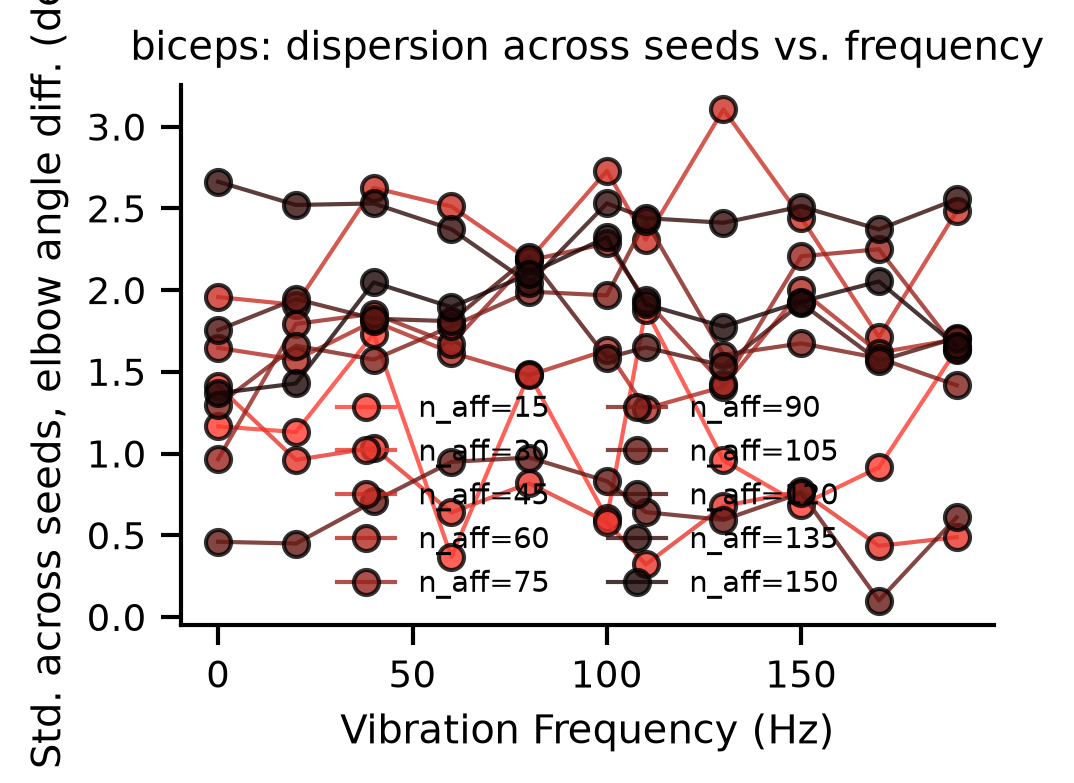

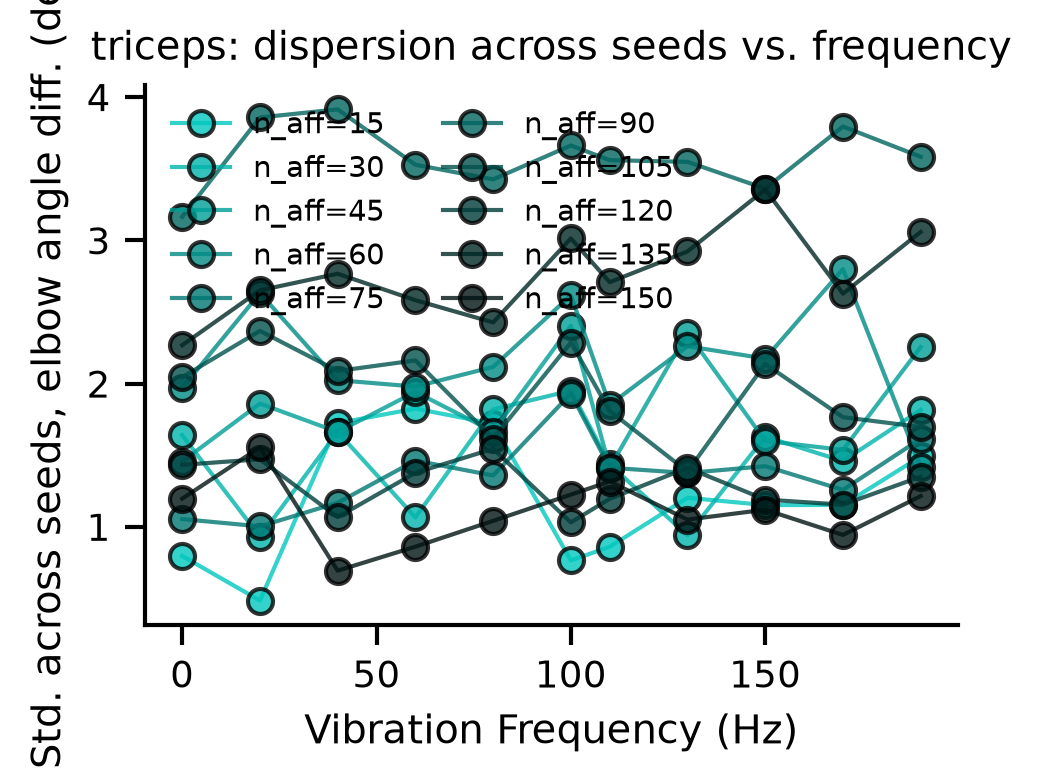

In [11]:
for label, base_color in [("biceps", original_hex_biceps), ("triceps", original_hex_tri)]:
    df_m = std_curves_df[std_curves_df["muscle_group"] == label]
    if df_m.empty:
        continue

    n_aff_here = sorted(df_m["n_aff"].unique())
    grad = generate_color_gradient(base_color, num_shades=len(n_aff_here))

    fig, ax = plt.subplots(figsize=BASE_FIG_SIZE_1COL)
    for i, n_aff in enumerate(n_aff_here):
        df_n = df_m[df_m["n_aff"] == n_aff].sort_values("vib_freq")
        ax.plot(
            df_n["vib_freq"],
            df_n["std_across_seeds"],
            color=grad[i],
            marker="o",
            markeredgecolor="black",
            alpha=ALPHA,
            lw=LW,
            markersize=6,
            label=f"n_aff={n_aff}",
        )

    ax.set_xlabel("Vibration Frequency (Hz)")
    ax.set_ylabel("Std. across seeds, elbow angle diff. (deg)")
    ax.set_title(f"{label}: dispersion across seeds vs. frequency")
    ax.legend(ncol=2, fontsize=7)

    plt.tight_layout()
    fname = os.path.join(FIG_C_DIR, f"std_across_seeds_vs_freq_{label}")
    plt.savefig(fname + ".svg", format="svg", bbox_inches="tight")
    plt.savefig(fname + ".png")
    plt.show()
    plt.close()

### Summary table: mean standard deviation across seeds, per (muscle group, n_aff)

20 values (2 rows x 10 columns) -- each cell is the frequency-averaged std-across-seeds curve from above.

In [12]:
std_table_path = os.path.join(FIG_DIR, "mean_std_across_seeds.csv")
std_table.to_csv(std_table_path)
print(f"saved mean-std table to {std_table_path}")
std_table

saved mean-std table to figures_spindle_scaling_analysis/mean_std_across_seeds.csv


n_aff,15,30,45,60,75,90,105,120,135,150
muscle_group,,,,,,,,,,
triceps,1.198312,1.486889,1.832337,2.167884,1.369706,3.582232,1.942297,1.293896,2.762369,1.111237
biceps,1.142720,0.740590,2.361665,1.614906,1.837583,1.725255,0.643898,1.773908,2.450568,1.863358


### Mean standard deviation vs. number of afferents

The 20-value table above, plotted as two lines (one per muscle group) against n_aff.

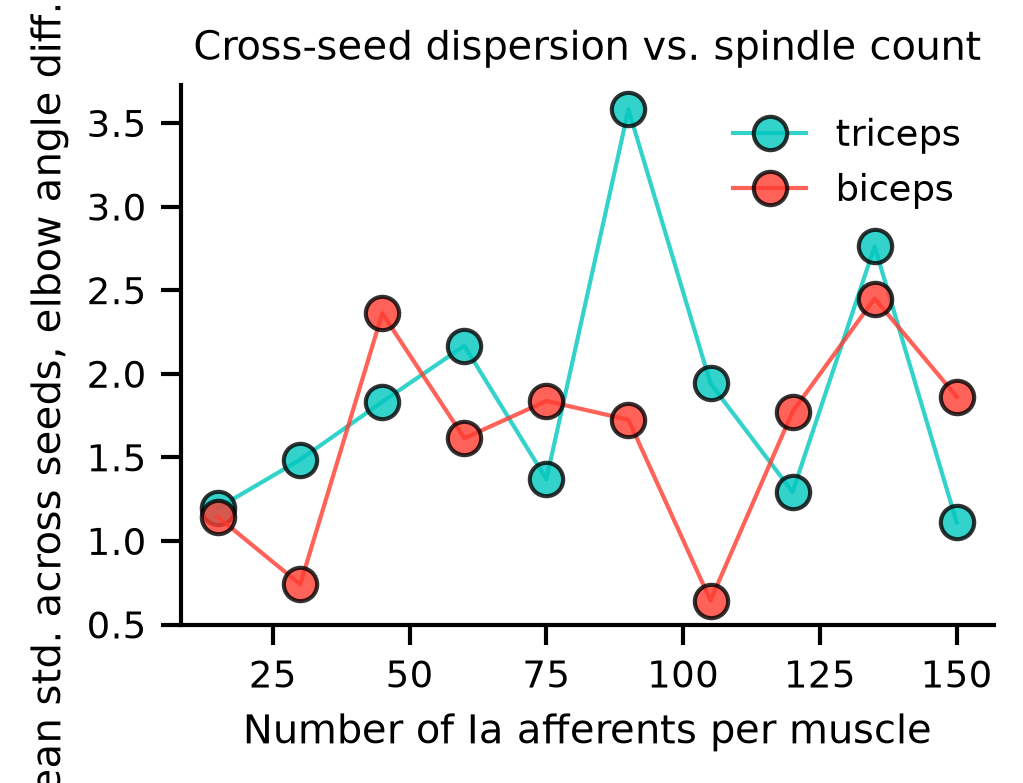

In [13]:
fig, ax = plt.subplots(figsize=BASE_FIG_SIZE_1COL)

for label, color in [("triceps", original_hex_tri), ("biceps", original_hex_biceps)]:
    if label not in std_table.index:
        continue
    row = std_table.loc[label].dropna().sort_index()
    ax.plot(
        row.index,
        row.values,
        color=color,
        marker="o",
        markeredgecolor="black",
        alpha=ALPHA,
        lw=LW,
        markersize=8,
        label=label,
    )

ax.set_xlabel("Number of Ia afferents per muscle")
ax.set_ylabel("Mean std. across seeds, elbow angle diff. (deg)")
ax.set_title("Cross-seed dispersion vs. spindle count")
ax.legend()

plt.tight_layout()
fname = os.path.join(FIG_D_DIR, "mean_std_across_seeds_vs_spindleCount")
plt.savefig(fname + ".svg", format="svg", bbox_inches="tight")
plt.savefig(fname + ".png")
plt.show()
plt.close()

## 6. Figure E: test-set performance vs. number of afferents

Genuine held-out test-set performance -- not the validation split carved out of the training data that `config.yaml`'s `validation_loss`/`validation_accuracy` reflect -- for every trained model. Computed by `inference/test_scaling_experiment_gpu.py` against `flag_pcr_os_test.hdf5`, a file the training sweep never touches. Uses each model's own stored normalization stats (`train_mean`/`train_std`/`label_mean`/`label_std` from its `config.yaml`) and the same loss/accuracy formulas `Trainer.eval()` uses during training, so these numbers are directly comparable to the logged validation numbers, just measured on genuinely unseen data.

**Run `python inference/test_scaling_experiment_gpu.py` first** (needs the GPU -- don't run it while the training sweep is still using it) -- like the vibration-test data, this isn't generated automatically; the cell below just loads its output CSV.

In [ ]:
TEST_PERF_PATH = os.path.join(EXPERIMENT_DIR, "test_performance.csv")

if not os.path.exists(TEST_PERF_PATH):
    print(
        f"No test_performance.csv found yet at {TEST_PERF_PATH} -- "
        "run `python inference/test_scaling_experiment_gpu.py` first."
    )
else:
    test_perf_df = pd.read_csv(TEST_PERF_PATH, dtype={"coeff_seed": str, "training_seed": str})
    test_perf_df = test_perf_df.sort_values(["coeff_seed", "n_aff"])

    seeds_present = sorted(test_perf_df["coeff_seed"].unique())
    # neutral (non-muscle-colored) shading, since this figure has no bicep/tricep axis
    seed_colors = generate_color_gradient("#333333", num_shades=len(seeds_present))
    # built locally rather than reusing the notebook-global seed_marker_map, so this
    # section works standalone even if the vibration-data cells above were never run
    figE_seed_marker_map = {seed: MARKER_LIST[i] for i, seed in enumerate(seeds_present)}

    # constrained_layout (not tight_layout(), which clipped the long rotated y-labels here
    # -- two subplots plus an external legend left too little margin for tight_layout's
    # single-pass sizing to get right) handles the spacing continuously and correctly
    fig, (ax_loss, ax_acc) = plt.subplots(
        1, 2, figsize=(BASE_FIG_SIZE_1COL[0] * 2.3, BASE_FIG_SIZE_1COL[1] * 1.15),
        constrained_layout=True,
    )
    handles = labels = None
    for i, seed in enumerate(seeds_present):
        df_seed = test_perf_df[test_perf_df["coeff_seed"] == seed]
        (line,) = ax_loss.plot(
            df_seed["n_aff"], df_seed["test_loss"],
            color=seed_colors[i], marker=figE_seed_marker_map[seed],
            markeredgecolor="black", alpha=ALPHA, lw=LW, markersize=8,
        )
        ax_acc.plot(
            df_seed["n_aff"], df_seed["test_accuracy"],
            color=seed_colors[i], marker=figE_seed_marker_map[seed],
            markeredgecolor="black", alpha=ALPHA, lw=LW, markersize=8,
        )
        if handles is None:
            handles, labels = [line], [f"seed {seed}"]
        else:
            handles.append(line)
            labels.append(f"seed {seed}")

    ax_loss.set_xlabel("Number of Ia afferents per muscle")
    ax_loss.set_ylabel("Test MSE loss (normalized)")
    ax_acc.set_xlabel("Number of Ia afferents per muscle")
    ax_acc.set_ylabel("Test accuracy: mean L2 dist. (normalized)")
    ax_acc.legend(handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0)

    fname = os.path.join(FIG_E_DIR, "test_performance_vs_spindleCount")
    fig.savefig(fname + ".svg", format="svg", bbox_inches="tight")
    fig.savefig(fname + ".png", bbox_inches="tight")
    plt.show()
    plt.close(fig)

    test_perf_df